In [ ]:
!pip install teneto --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.1/229.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.5/708.5 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 5.4 MB/s eta 0:00:00


TCTC: Temporal Communities by Trajectory Clustering (Comunidades Temporales por Agrupamiento de Trayectorias). Es un algoritmo diseñado para encontrar comunidades temporales en datos de series de tiempo.

El tipo de datos necesarios para TCTC son múltiples series de tiempo provenientes de nodos en una red.

La mayoría de la detección de comunidades requiere crear primero un paso de "inferencia de aristas" TCTC no. Primero encuentra *clústers* de trayectorias en las series de tiempo sin inferir aristas. El agrupamiento de trayectorias intenta agrupar nodos que tienen caminos similares a través de un espacio.

Los hiperparámetros de TCTC dictan qué tipo de trayectoria se encuentra en los datos. Hay cuatro hiperparámetros:
- Un parámetro de distancia máxima ($\epsilon$): La distancia entre todos los nodos que forman parte de la misma trayectoria debe ser $\epsilon$ o menor.
- Un parámetro de tamaño mínimo ($\sigma$). Todas las trayectorias deben incluir al menos $\sigma$ nodos.
- Un parámetro de tiempo mínimo ($\tau$). Todas las trayectorias deben persistir durante $\tau$ puntos de tiempo.
- Un parámetro de tolerancia ($\kappa$). Pueden existir $\kappa$ puntos de tiempo de "excepción" consecutivos antes de que termine la trayectoria.

El algoritmo está especializado en estimar cimunidades temporales de datos en nodos. Sale del arítuclo [*The identification of temporal communities
through trajectory clustering correlates with
single-trial behavioural fluctuations in
neuroimaging data*](https://www.biorxiv.org/content/10.1101/617027v1.full.pdf) de 2019.



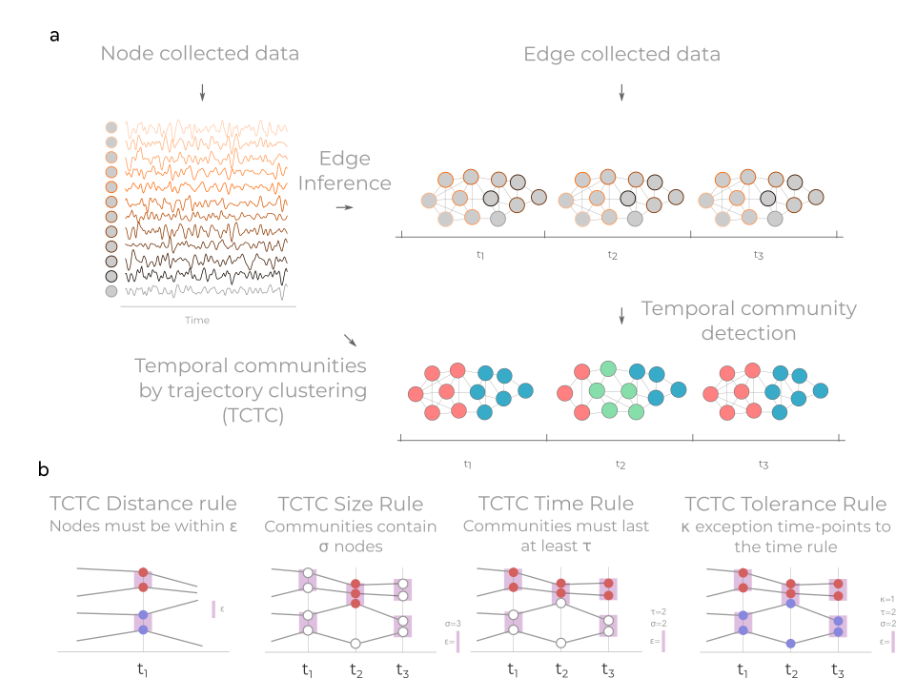

Si dos nodos pertenecen a la misma comunidad en un momento dado, se registra un enlace.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from teneto.communitydetection import tctc
import pandas as pd

In [ ]:
t1 = np.concatenate([np.zeros(5), np.ones(5), np.full(5, 2), np.full(5, 3)]).astype(float)
t2 = np.concatenate([np.zeros(4), np.ones(6), np.full(6, 2), np.full(4, 3)]).astype(float)
t3 = np.concatenate([np.ones(3), np.zeros(2), np.ones(5), np.full(5, 2), np.full(5, 3)]).astype(float)
t4 = np.concatenate([np.full(3, -1), np.zeros(2), np.ones(5), np.zeros(5), np.full(5, -1)]).astype(float)
t5 = np.arange(0, 20).astype(float)

#Matriz de datos
data_base = np.array([t1, t2, t3, t4, t5]) #5 nodos , 20 tiempos
data = data_base.transpose()
#Ruido uniforme
np.random.seed(42)
data += np.random.uniform(-0.2, 0.2, data.shape)

#Convertimos a DataFrame
columns = [f'Trayectoria_{i+1}' for i in range(5)]
df = pd.DataFrame(data, columns=columns)
df.index.name = 'Tiempo'

display(df)

,Trayectoria_1,Trayectoria_2,Trayectoria_3,Trayectoria_4,Trayectoria_5
Tiempo,,,,,
0,-0.050184,0.180286,1.092798,-0.960537,-0.137593
1,-0.137602,-0.176767,1.146470,-0.959554,1.083229
2,-0.191766,0.187964,1.132977,-1.115064,1.872730
3,-0.126638,-0.078303,0.009903,-0.027222,2.916492
4,0.044741,0.855798,-0.083142,-0.053455,3.982428
5,1.114070,0.879870,1.005694,1.036966,4.818580
6,1.043018,0.868210,0.826021,1.179554,6.186253
7,1.123359,0.921846,0.839069,1.073693,6.976061
8,0.848815,0.998071,0.813755,1.163728,7.903512


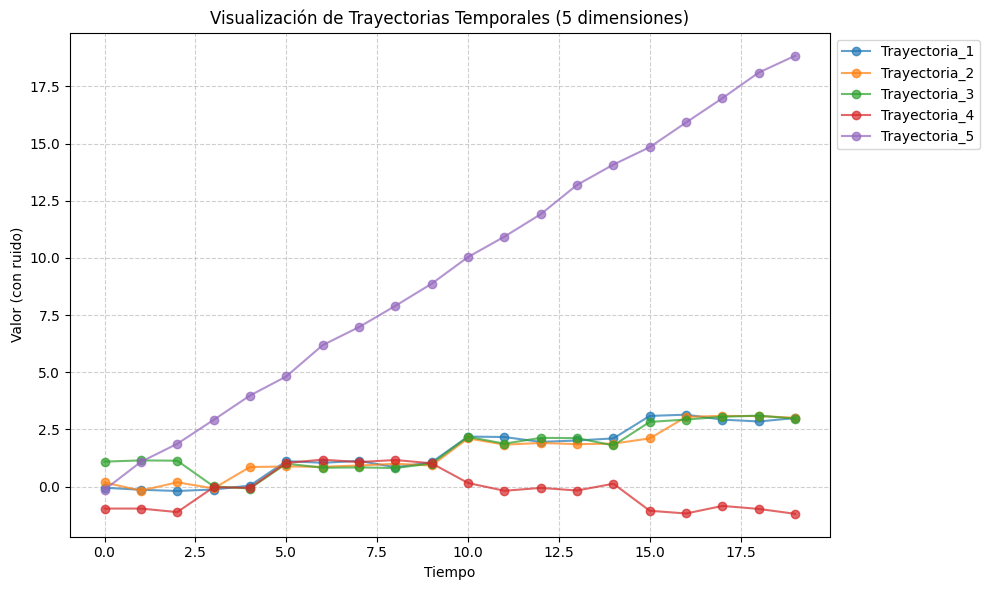

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df, marker='o', alpha=0.7)

ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor (con ruido)')
ax.set_title('Visualización de Trayectorias Temporales (5 dimensiones)')
ax.legend(columns, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Existen 2 posibles outputs:

* Arreglo binario (dimensiones: nodo, nodo, tiempo), donde cada valor 1 indica que dos nodos pertenecen a la misma comunidad.

* Dataframe, donde cada fila representa una comunidad.

In [ ]:
parameters = {
'epsilon': 0.5,
'tau': 3,
'sigma': 2,
'kappa': 0
}
tctc_array = tctc(data, **parameters)
print(tctc_array.shape)
tctc_df = tctc(data, **parameters, output='df')
tctc_df.head()

(5, 5, 20)


,community,start,end,size,length
0,"[0, 1]",0,4,2.0,4
1,"[0, 2, 3]",3,10,3.0,7
2,"[0, 1, 2, 3]",5,10,4.0,5
3,"[0, 1, 2]",5,15,3.0,10
4,"[0, 2]",5,20,2.0,15


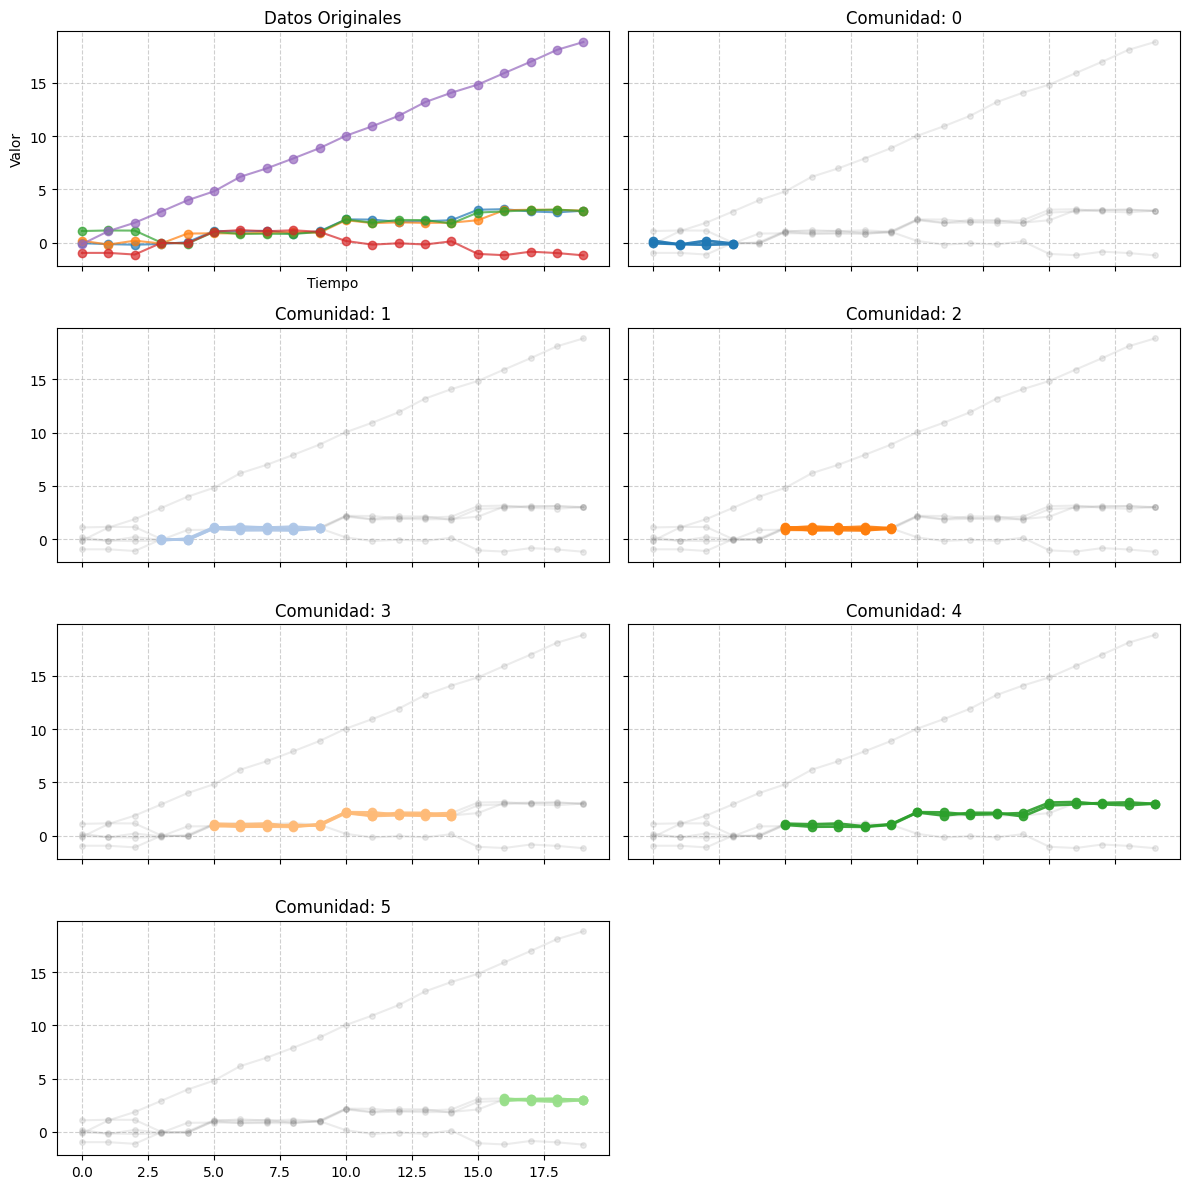

In [ ]:
def community_plot(df, data):
  nrows = int(np.ceil((len(df)+1)/2))
  fig, ax = plt.subplots(nrows, 2, sharex=True, sharey=True, figsize=(12, 3*nrows))
  ax = ax.flatten()

  ax[0].plot(data, marker='o', alpha=0.7)
  ax[0].set_xlabel('Tiempo')
  ax[0].set_ylabel('Valor')
  ax[0].set_title('Datos Originales')
  ax[0].grid(True, linestyle='--', alpha=0.6)

  for i, row in enumerate(df.iterrows()):
    ax[i+1].plot(data, alpha=0.15, color='gray', marker='o', markersize=4)
    ax[i+1].plot(np.arange(row[1]['start'],row[1]['end']),data[row[1]['start']:row[1]['end'], row[1]['community']],color=plt.cm.tab20.colors[i % 20], marker='o', alpha=0.9, linewidth=2)
    ax[i+1].set_title('Comunidad: ' + str(i))
    ax[i+1].grid(True, linestyle='--', alpha=0.6)

  for j in range(len(df)+1, len(ax)):
    fig.delaxes(ax[j])

  plt.tight_layout()
  return fig, ax

fig, ax = community_plot(tctc_df, data)

# Cambiando parámetros

## Épsilon

Si hacemos ϵ más grande, incluiremos más series de tiempo en una trayectoria. Sin embargo, esto puede significar que las comunidades que detectas estén menos "conectadas" que si ϵ fuera más pequeño.

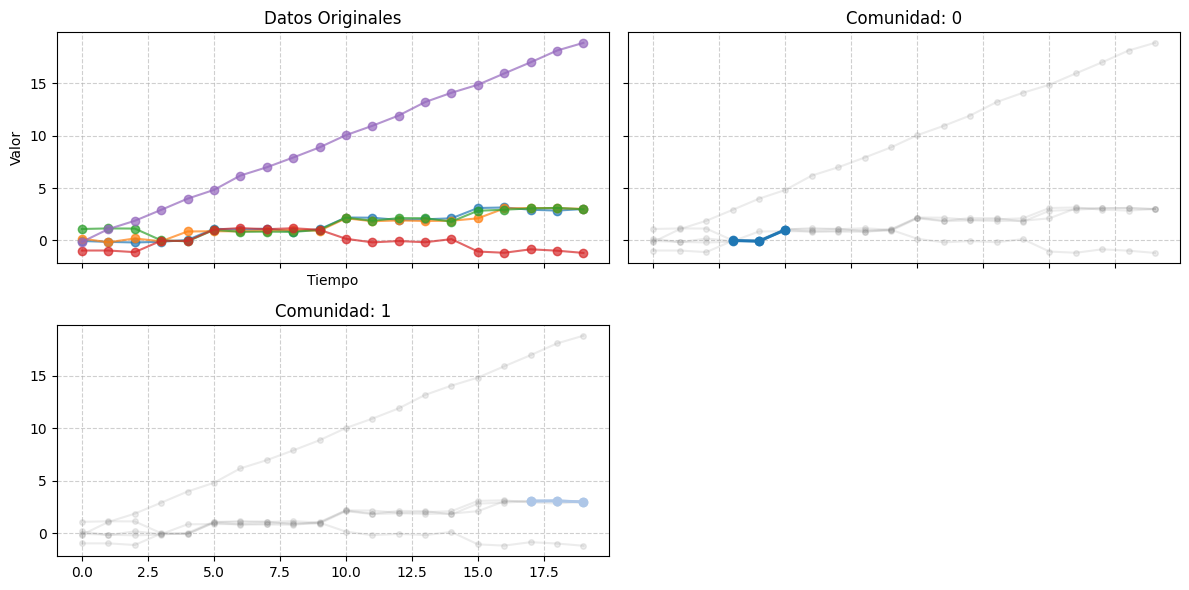

In [ ]:
parameters = {
'epsilon': 0.05,
'tau': 3,
'sigma': 2,
'kappa': 0
}
tctc_df_largeep = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_largeep, data)

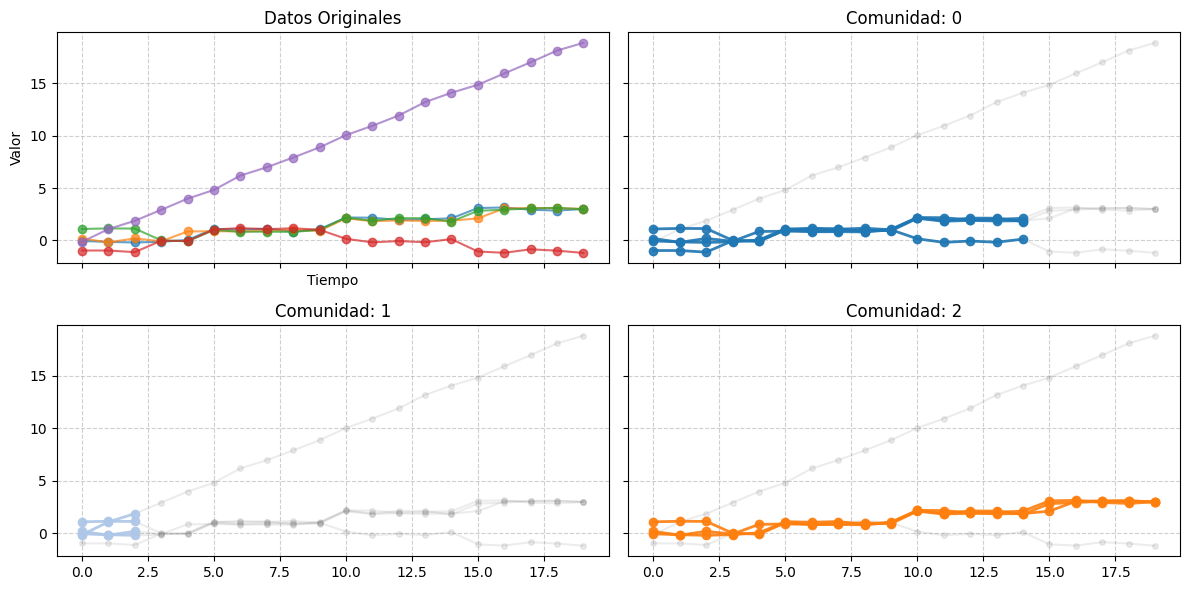

In [ ]:
parameters = {
'epsilon': 2.5,
'tau': 3,
'sigma': 2,
'kappa': 0
}
tctc_df_largeep = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_largeep, data)

## Tau

Si hacemos $\tau$ más grande, requerirá que las trayectorias persistan durante más puntos de tiempo. Las trayectorias más cortas aumentan la probabilidad de conexiones más ruidosas.

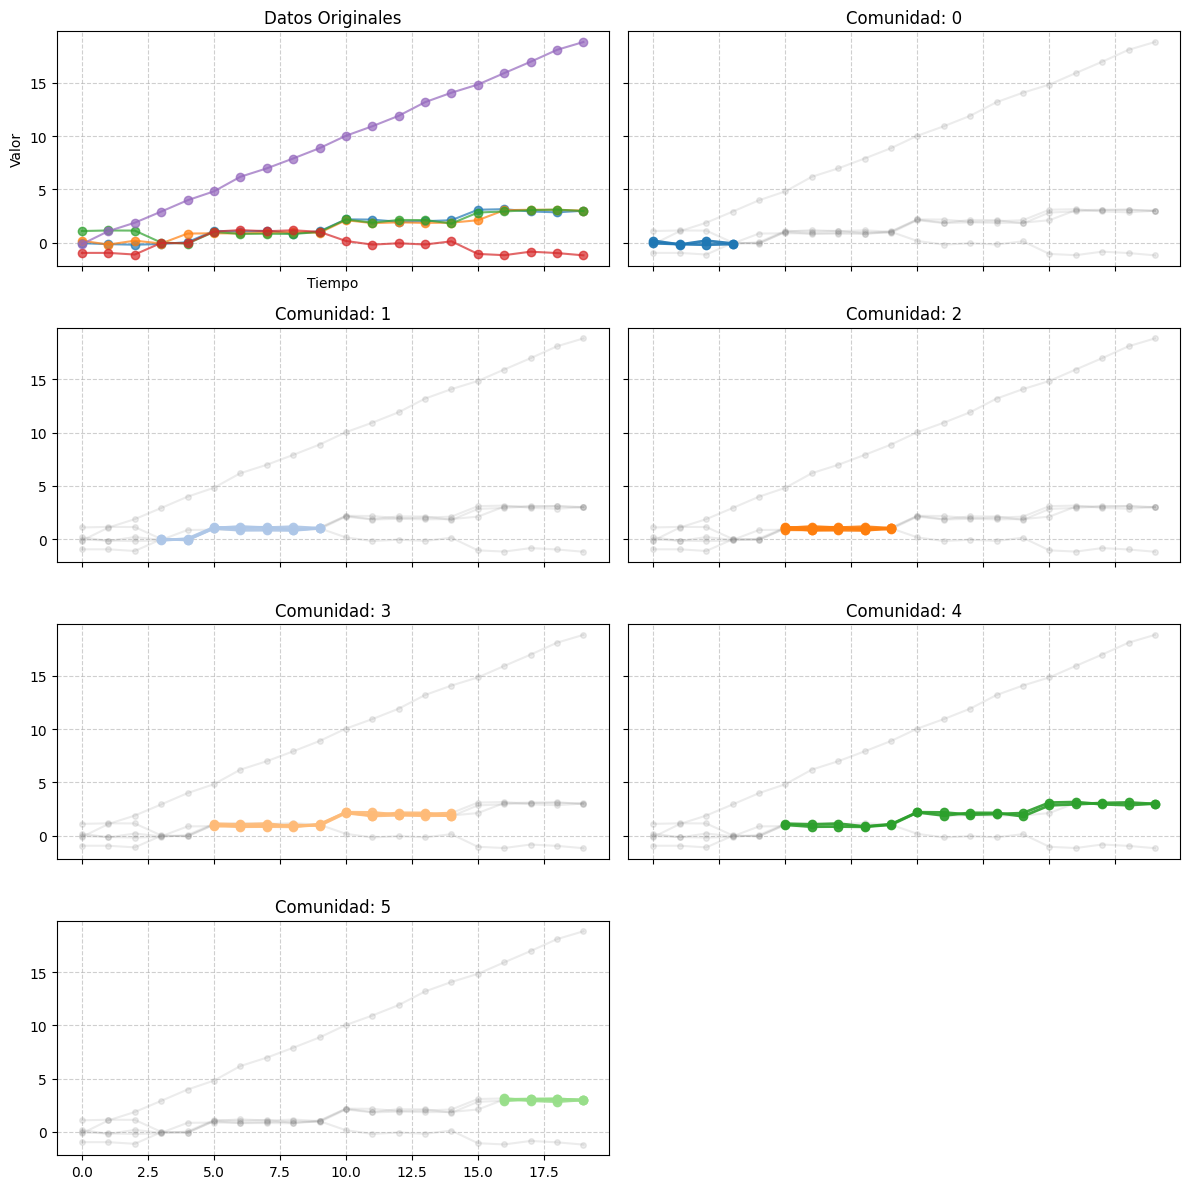

In [ ]:
parameters = {
'epsilon': 0.5,
'tau': 2,
'sigma': 2,
'kappa': 0
}
tctc_df_shorttau = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_shorttau, data)

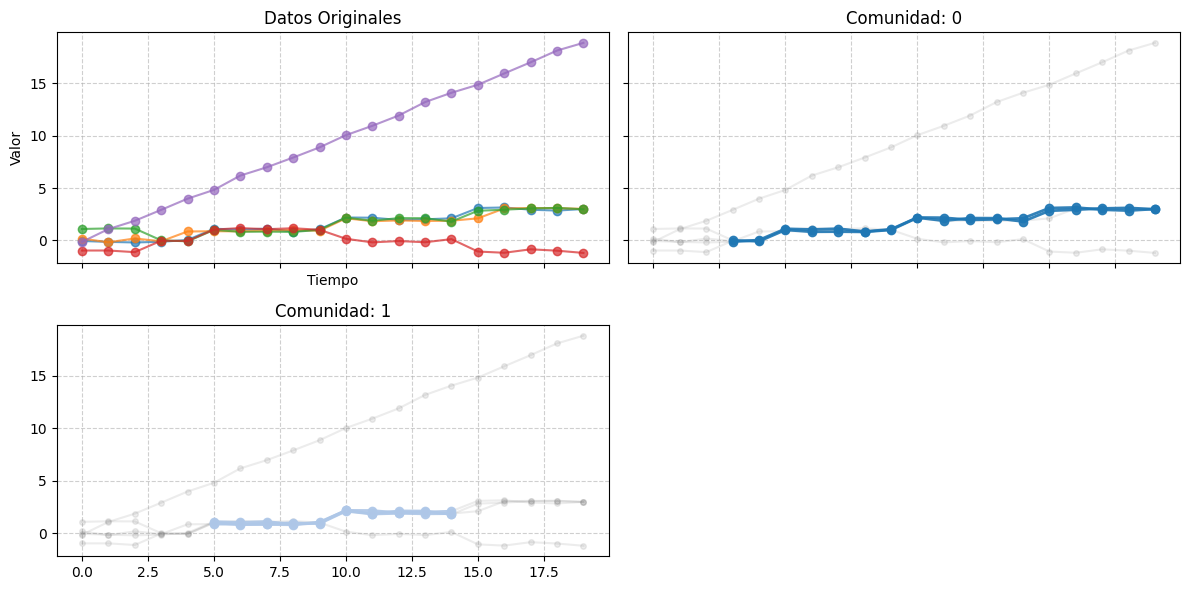

In [ ]:
parameters = {
'epsilon': 0.5,
'tau': 8,
'sigma': 2,
'kappa': 0
}
tctc_df_shorttau = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_shorttau, data)

## Sigma
Si hacemos $\sigma$ más grande, requerirá que más nodos formen parte de la trayectoria. Valores más pequeños de $\sigma$ darán como resultado posibles conexiones más ruidosas.

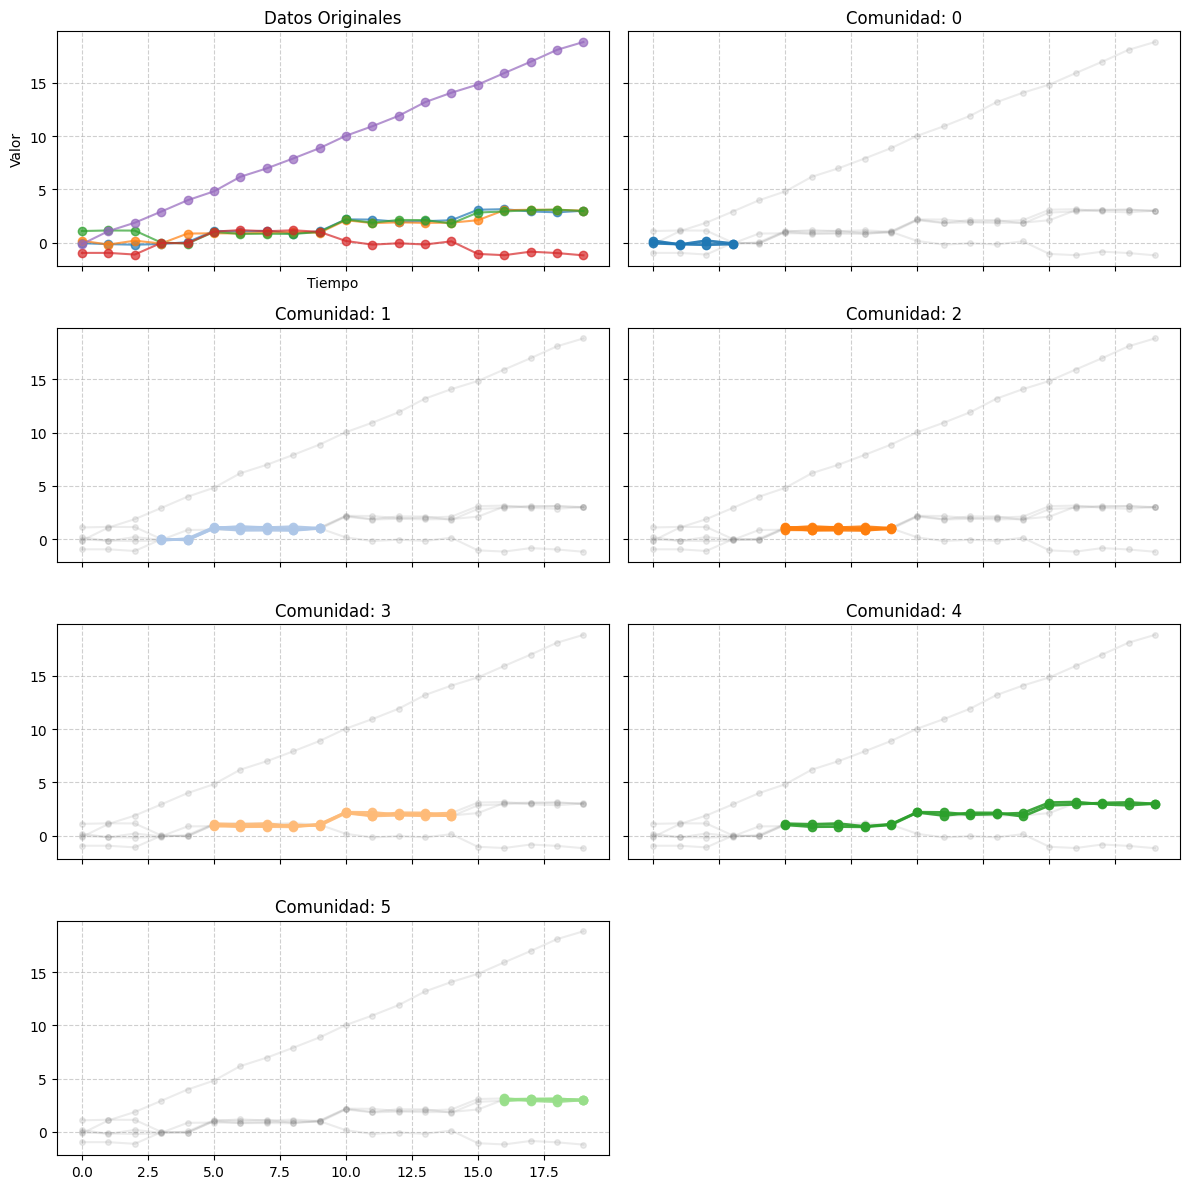

In [ ]:
parameters = {
'epsilon': 0.5,
'tau': 3,
'sigma': 1.5,
'kappa': 0
}
tctc_df_longsigma = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_longsigma, data)

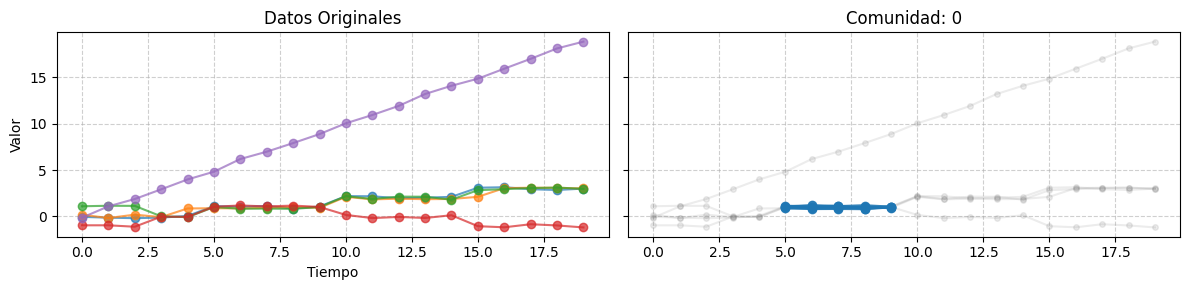

In [ ]:
parameters = {
'epsilon': 0.5,
'tau': 3,
'sigma': 4,
'kappa': 0
}
tctc_df_longsigma = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_longsigma, data)

## Kappa

Si hacemos $\kappa$ más grande, permitirá que exista esa cantidad de puntos de tiempo "ruidosos" antes de corta la trayectoria.

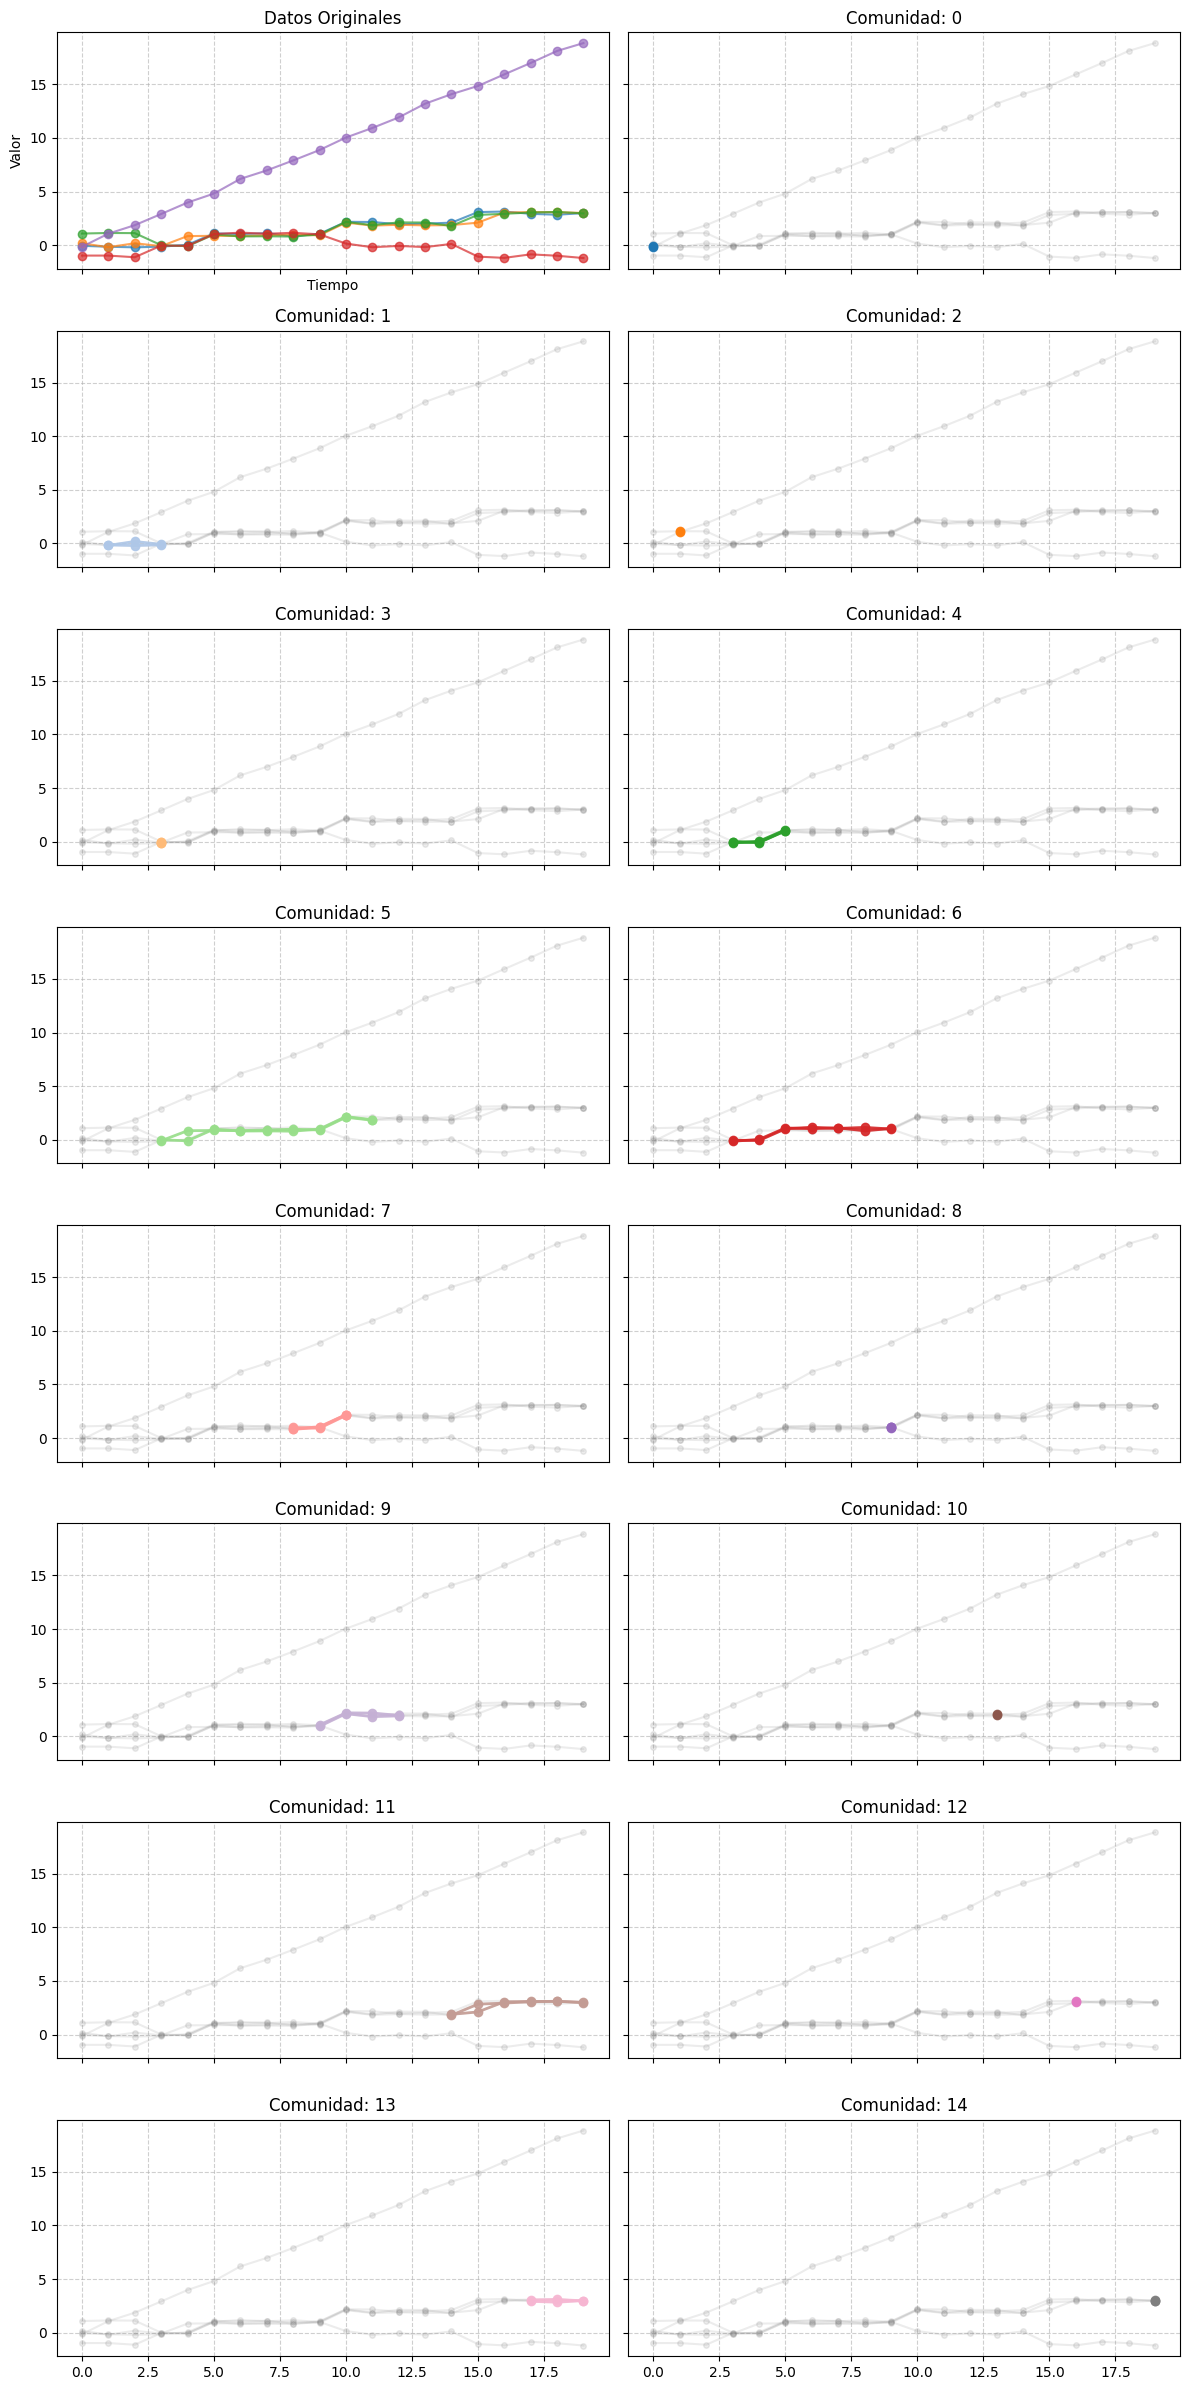

In [ ]:
parameters = {
'epsilon': 0.15,
'tau': 1,
'sigma': 2,
'kappa': 1
}
tctc_df_withkappa = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_withkappa, data)

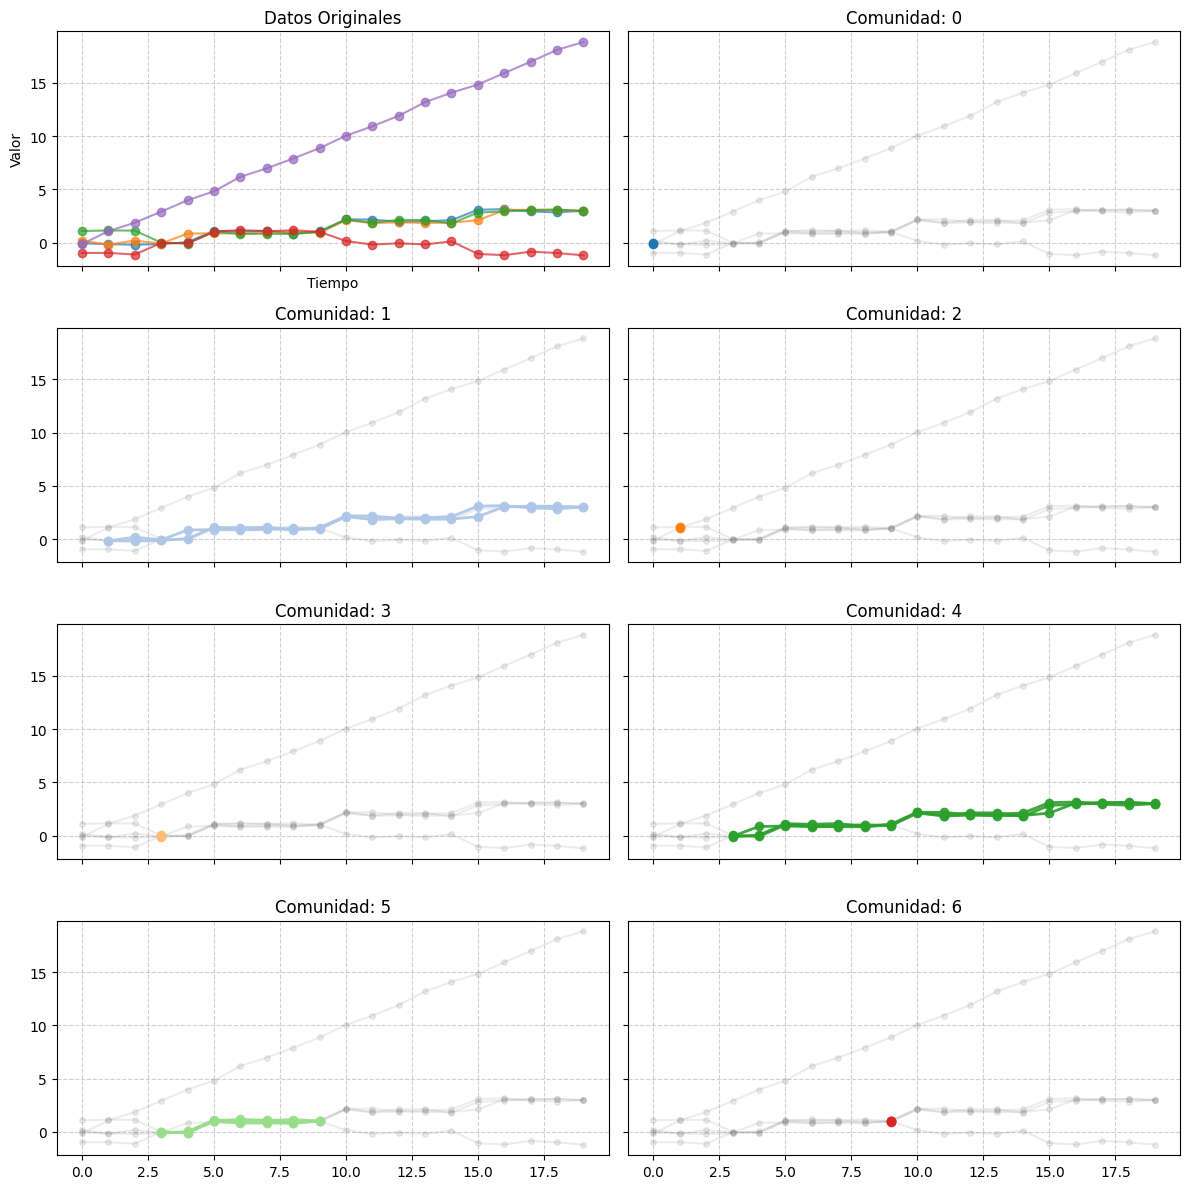

In [ ]:
parameters = {
'epsilon': 0.15,
'tau': 1,
'sigma': 2,
'kappa': 4
}
tctc_df_withkappa = tctc(data, **parameters, output='df')
fig, ax = community_plot(tctc_df_withkappa, data)

/tmp/ipykernel_3807/2060487686.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, period='15d')['Close']
[*********************100%***********************]  4 of 4 completed


,community,start,end,size,length
0,"[1, 2]",0,14,2.0,14
1,"[1, 2, 3]",4,11,3.0,7
2,"[0, 3]",9,15,2.0,6
7,"[2, 3]",4,13,2.0,9


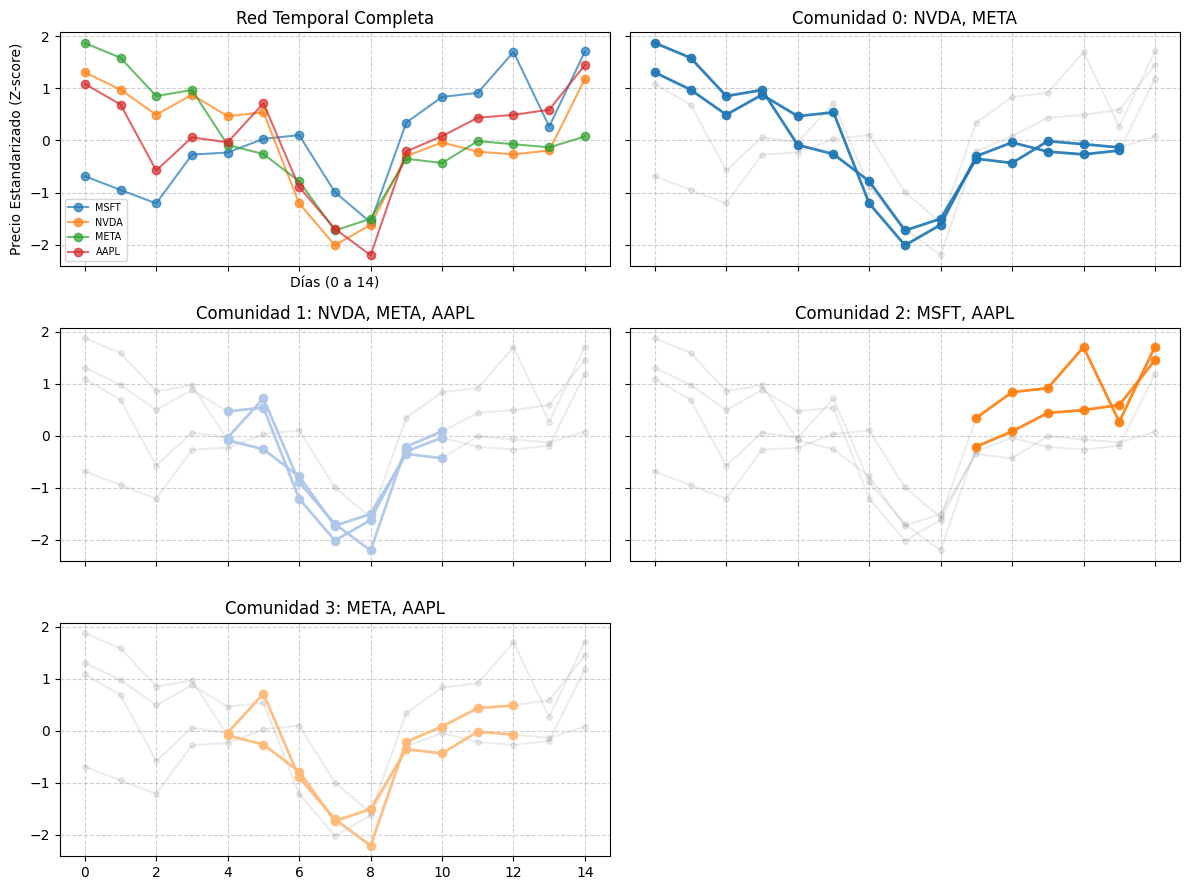

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['MSFT', 'NVDA', 'META', 'AAPL']
df_raw = yf.download(tickers, period='15d')['Close']
df_norm = (df_raw - df_raw.mean()) / df_raw.std()

data_tensor = df_norm.values

parametros = {
    'epsilon': 0.6,  #Distancia permisible
    'sigma': 2,      #Mínimo 2 acciones para considerar que hay un "sector" o comunidad
    'tau': 3,        #Deben moverse juntas durante al menos 3 días consecutivos
    'kappa': 1       #Perdonamos 1 día de volatilidad donde se separen
}

tctc_df = tctc(data_tensor, **parametros, output='df')
display(tctc_df)

def community_plot(df, data, labels):
    #Si el algoritmo no encontró comunidades
    if len(df) == 0:
        print("\nEl algoritmo no detectó comunidades. Intenta subir epsilon o bajar tau.")
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(data, marker='o', alpha=0.7)
        ax.legend(labels)
        plt.title("Nodos de la Red (Sin comunidades detectadas)")
        return fig, ax

    nrows = int(np.ceil((len(df)+1)/2))
    fig, ax = plt.subplots(nrows, 2, sharex=True, sharey=True, figsize=(12, 3*nrows))
    ax = ax.flatten()

    #Gráfica de nodos
    ax[0].plot(data, marker='o', alpha=0.7)
    ax[0].set_xlabel('Días (0 a 14)')
    ax[0].set_ylabel('Precio Estandarizado (Z-score)')
    ax[0].set_title('Red Temporal Completa')
    ax[0].legend(labels, loc='best', fontsize='x-small')
    ax[0].grid(True, linestyle='--', alpha=0.6)

    #Dibujar cada comunidad detectada
    for i, row in enumerate(df.iterrows()):
        ax[i+1].plot(data, alpha=0.15, color='gray', marker='o', markersize=4)
        ax[i+1].plot(
            np.arange(row[1]['start'], row[1]['end']),
            data[row[1]['start']:row[1]['end'], row[1]['community']],
            color=plt.cm.tab20.colors[i % 20], marker='o', alpha=0.9, linewidth=2
        )

        #Mapear los índices a sus acciones MSFT, NVDA, META, AAPL
        nombres_nodos = [labels[n] for n in row[1]['community']]
        ax[i+1].set_title(f"Comunidad {i}: {', '.join(nombres_nodos)}")
        ax[i+1].grid(True, linestyle='--', alpha=0.6)

    for j in range(len(df)+1, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()
    return fig, ax

fig, ax = community_plot(tctc_df, data_tensor, tickers)
if fig:
    plt.show()

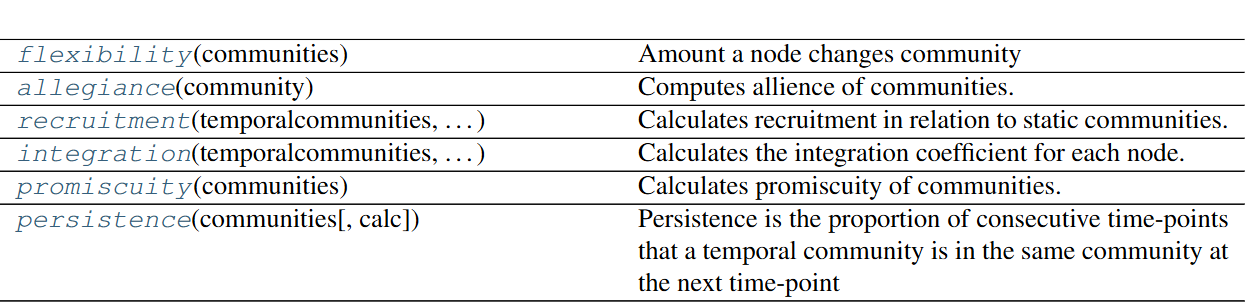

In [ ]:
import numpy as np
import pandas as pd
from teneto.communitydetection import tctc
from teneto.communitymeasures import flexibility, allegiance, promiscuity, persistence

parametros_tctc = {
    'epsilon': 0.6,
    'sigma': 2,
    'tau': 3,
    'kappa': 1
}

#'data_tensor' (15x4) y 'tickers' ['MSFT', 'NVDA', 'META', 'AAPL']
tctc_df = tctc(data_tensor, **parametros_tctc, output='df')

N = 4   #Acciones
T = 15  #Días
comunidades_array = np.full((N, T), np.nan)

for i, row in tctc_df.iterrows():
    nodos = row['community']
    inicio = int(row['start'])
    fin = int(row['end'])

    for n in nodos:
        comunidades_array[n, inicio:fin] = i

print("--- Flexibilidad (Saltos entre comunidades) ---")
flex = flexibility(comunidades_array)
df_flex = pd.DataFrame({'Acción': tickers, 'Flexibilidad': flex})
display(df_flex)

print("\n--- Promiscuidad (En cuántos grupos distintos participó) ---")
prom = promiscuity(comunidades_array)
df_prom = pd.DataFrame({'Acción': tickers, 'Promiscuidad': prom})
display(df_prom)

print("\n--- Persistencia (Probabilidad de seguir en el mismo grupo mañana) ---")
pers = persistence(comunidades_array)
df_pers = pd.DataFrame({'Acción': tickers, 'Persistencia': pers})
display(df_pers)

print("\n--- Matriz de Lealtad (Probabilidad de estar en la misma comunidad) ---")
alleg = allegiance(comunidades_array)
df_alleg = pd.DataFrame(alleg, index=tickers, columns=tickers)
display(df_alleg)

--- Flexibilidad (Saltos entre comunidades) ---


,Acción,Flexibilidad
0,MSFT,0.642857
1,NVDA,0.214286
2,META,0.214286
3,AAPL,0.357143



--- Promiscuidad (En cuántos grupos distintos participó) ---


,Acción,Promiscuidad
0,MSFT,0.25
1,NVDA,0.50
2,META,0.50
3,AAPL,0.50



--- Persistencia (Probabilidad de seguir en el mismo grupo mañana) ---


,Acción,Persistencia
0,MSFT,0.642857
1,NVDA,0.642857
2,META,0.642857
3,AAPL,0.642857



--- Matriz de Lealtad (Probabilidad de estar en la misma comunidad) ---


,MSFT,NVDA,META,AAPL
MSFT,NaN,0.000000,0.000000,0.133333
NVDA,0.000000,NaN,0.333333,0.000000
META,0.000000,0.333333,NaN,0.600000
AAPL,0.133333,0.000000,0.600000,NaN
